In [222]:
import koran as k
import plotly_express as px

In [223]:
import importlib; importlib.reload(k);

# Data Model

**DOC**
- Lines from the source text, including OHCO.
- Consider calling _LINE_.

**CHAP**
- Joined lines from DOC by OHCO level, e.g. chapter.
- Used to pass to SKL's count vectorizor if used.
- _Consider not creating this here_.

**TOKEN**
- Split lines from DOC, preserving OHCO.

**CHUNK**
- Assigned feature to TOKEN, as pseudo OHCO level (non-nested).
- Used to group tokens into chunks for TFIDF, etc..
- Begins as empty df.

**CTM**
- Chunk-Term Count Matrix.

**VOCAB**
- Unique normalized terms extracted from TOKEN or CTM.
- Significance computed in based of document frequency, number of docs (chunks) that contain the term.

**TFIDF**
- Term significance matrix by computed from CTM with SciKit Learn.

**TFIDF_SIM**
- Pairwise cosine similarity matrix of chunks over TFIDF.

**TREE**
- Hiearchical data from clustering TFIDF_SIM.

**CLUSTER**
- Information about clusters based on threshold.

**PCA** and **LOADING**
- Results of PCA applied to TFIDF_SIM

**THETA**, **PHI**, and **TOPIC**

In [224]:
k.get_data()
k.create_doc_df()
k.DOC = k.DOC.query("line_str != 'In the name of God, the Gracious, the Merciful.'")
k.create_chap_df()
k.create_token_df()

In [278]:
k.TOKEN.to_csv("koran-TOKEN.csv", index=True)

In [225]:
k.TOKEN

token_str term_str
chap_num verse_num token_num                   
1        2         0            Praise   praise
                   1                be       be
                   2                to       to
                   3              God,      god
                   4              Lord     lord
...                                ...      ...
114      6         1             among    among
                   2              jinn     jinn
                   3               and      and
                   4             among    among
                   5          people.”   people

[139027 rows x 2 columns]

In [226]:
k.n_chunks = 100 # Value can be changed
k.create_chunk_df()

In [227]:
k.define_doc_df(k.CHUNK)

In [228]:
k.create_ctm_df()
k.extract_vocab_df()
k.add_stopwords()
k.compute_term_significance()
k.create_tfidf_df()

<Figure size 640x480 with 0 Axes>

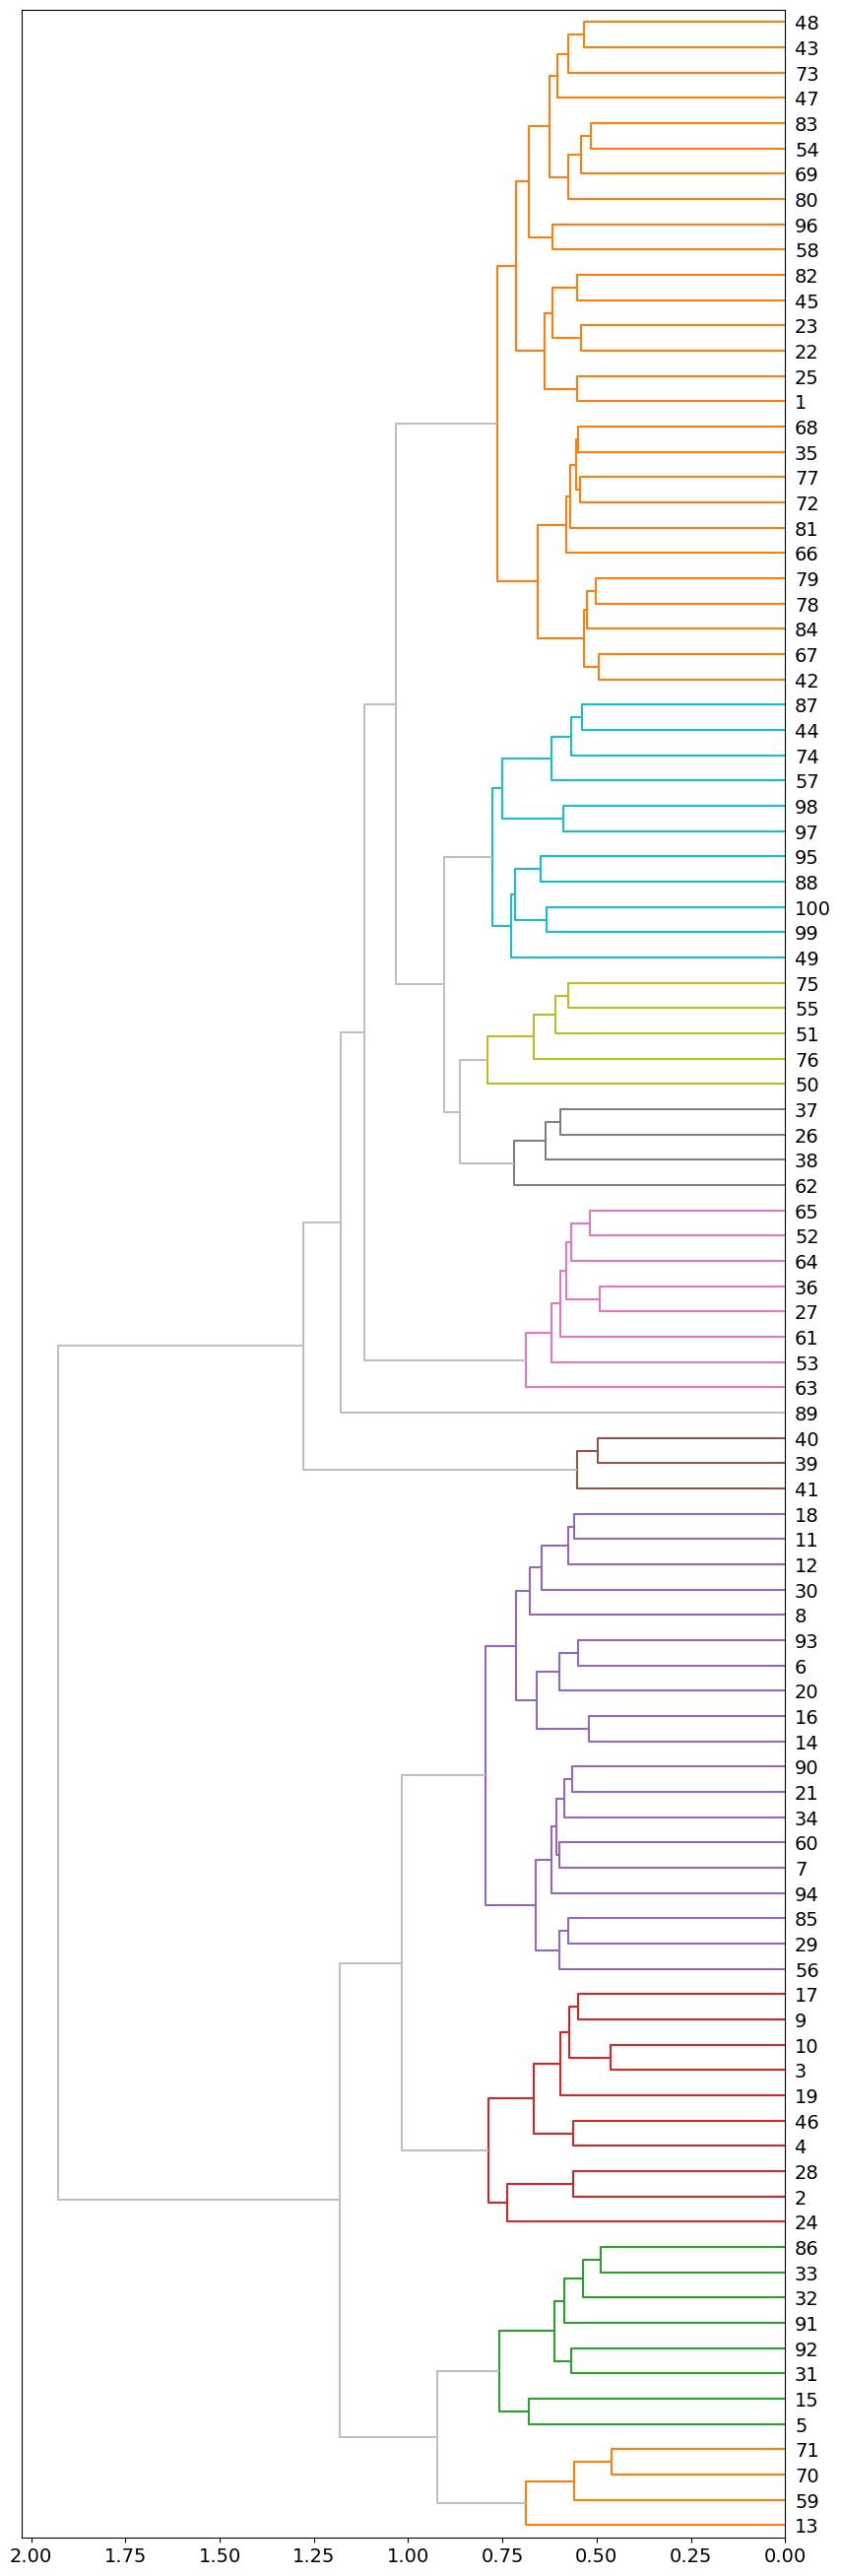

In [229]:
k.config['color_thresh'] = .8
k.cluster_by_docsim()
k.tfidf_hac.plot()

In [230]:
k.create_cluster_df()
k.create_cluster_chunk_df()
k.create_cluster_tfidf()
k.assign_cluster_tfidf_values()

In [231]:
k.compute_pca()
k.compute_nmf_topics()
k.assign_max_topics()
k.compute_theta_seq()

In [232]:
k.define_doc2_df(k.CHAP)
k.apply_topic_model()

In [233]:
k.DOC2_TOPIC_THETA

,0,1,2,3,4,5,6,7,8,9,10
chap_num,,,,,,,,,,,
1,1.866030e-01,5.293932e-07,2.561290e-01,4.317437e-13,5.650253e-14,4.548308e-02,3.544036e-08,1.552283e-26,1.509795e-22,1.363640e-31,8.209275e-09
2,3.109261e-02,1.360845e-01,2.088771e-01,1.309255e-02,9.305246e-03,1.488404e-02,8.073751e-03,8.589543e-09,1.682373e-02,2.523161e-02,2.191315e-02
3,5.544466e-02,1.560184e-01,1.723538e-01,1.103393e-17,5.495616e-10,2.881264e-02,1.961173e-02,1.620737e-06,2.533673e-03,4.223387e-02,3.152993e-03
4,2.765573e-14,1.342765e-01,8.766463e-02,3.349978e-16,2.133879e-16,3.748403e-38,8.118398e-02,1.854199e-28,6.303946e-21,1.641899e-01,2.772151e-02
5,2.633313e-02,1.202558e-01,2.565034e-01,5.450925e-10,2.614781e-14,3.218337e-17,2.074710e-07,3.632382e-04,3.420189e-02,4.407710e-02,3.669405e-26
...,...,...,...,...,...,...,...,...,...,...,...
110,1.943085e-31,2.261006e-28,5.343099e-33,2.616008e-31,9.629656e-41,1.037809e-17,1.944647e-38,7.514932e-28,1.060565e-28,4.943361e-01,3.589242e-02
111,1.943085e-31,2.261006e-28,5.343099e-33,2.616008e-31,9.629656e-41,1.037809e-17,1.944647e-38,7.514932e-28,1.060565e-28,4.943361e-01,3.589242e-02
112,1.943085e-31,2.261006e-28,5.343099e-33,2.616008e-31,9.629656e-41,1.037809e-17,1.944647e-38,7.514932e-28,1.060565e-28,4.943361e-01,3.589242e-02


In [234]:
k.create_doc2_topic_theta_sim()

In [235]:
k.create_part_df()

In [236]:
k.TOPIC

,top_terms,gloss
topic_id,,
0,"humiliating, rejoice, suddenly, merges, univer...",humiliating
1,"fight, possessions, persons, loves, supporters...",fight
2,"torah, sabbath, mary, christians, messiah, jew...",torah
3,"throw, magician, troops, ta, river, threw, sta...",throw
4,"joseph, prison, caravan, interpretation, broth...",joseph
5,"drinks, bones, deny, easts, guarded, woe, zech...",drinks
6,"wives, pathways, sisters, marry, properties, f...",wives
7,"hud, lot, saleh, dwellings, overtook, shuaib, ...",hud
8,"testimony, excessive, accountable, tasted, clo...",testimony


In [237]:
k.pd.concat(
    [k.PHI.T[t].sort_values(ascending=False).to_frame('w').reset_index()
     for t in range(k.k)], axis=1, keys=[i for i in range(k.k)]
).head(20).style.background_gradient(cmap="YlGnBu")

In [238]:
import seaborn as sns

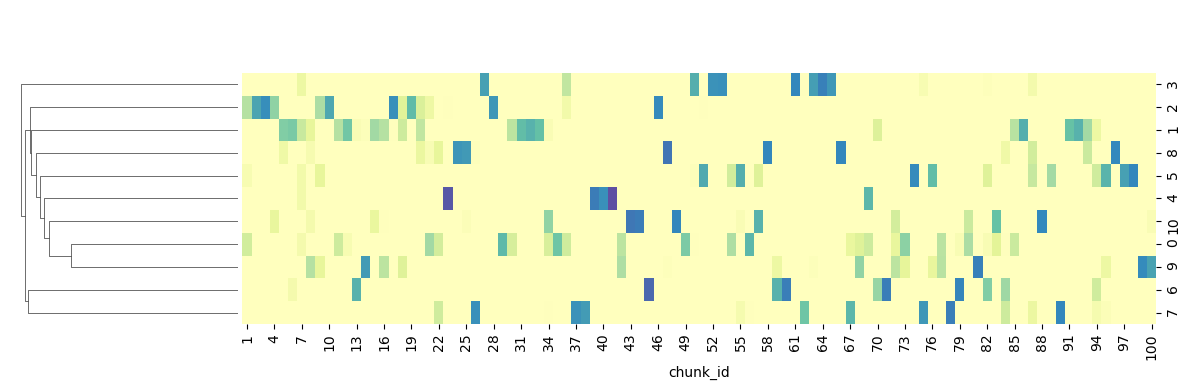

In [276]:
# k.THETA.columns = k.TOPIC.gloss
fig = sns.clustermap(k.THETA.T, 
                     cmap='Spectral', method='ward',
                     cbar_pos=None, center=0, 
                     row_cluster=True, 
                     col_cluster=False,
                    figsize=(12, 4))

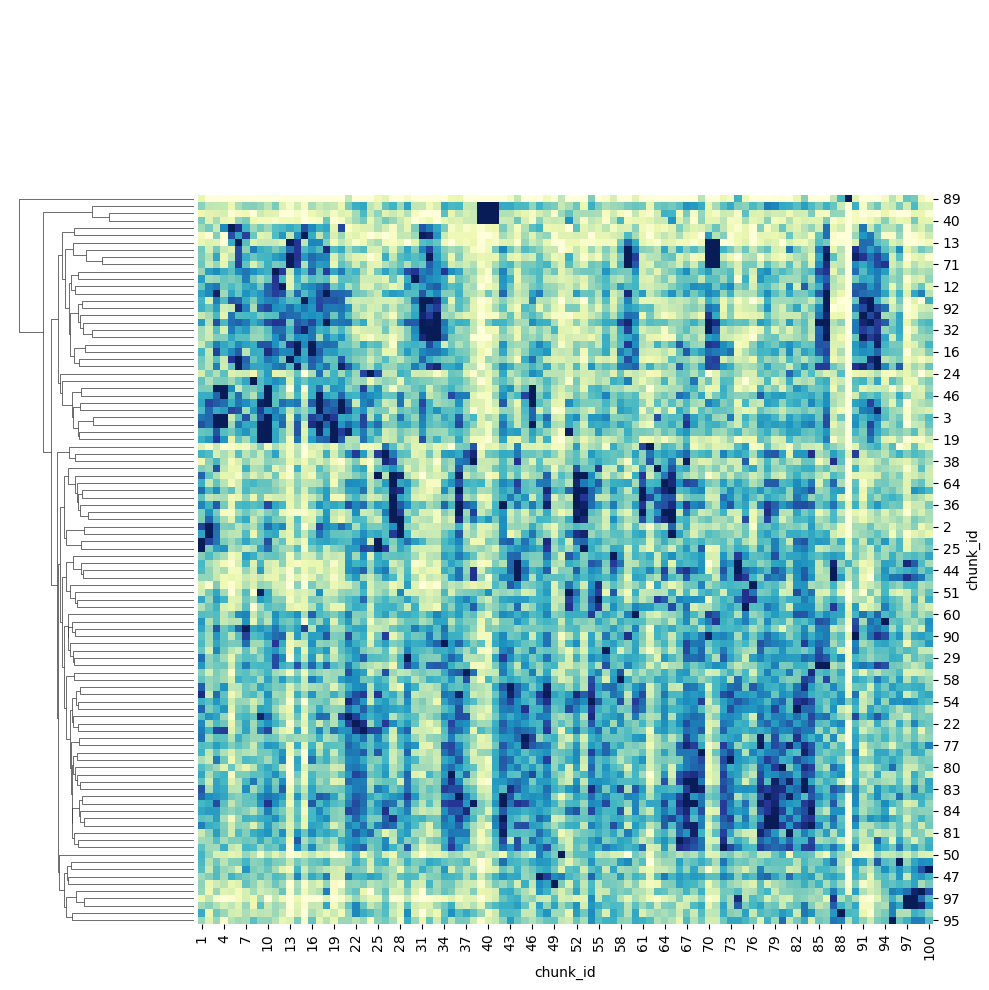

In [277]:
sns.clustermap(k.TFIDF_SIM, col_cluster=False, robust=True, cbar_pos=None, cmap="YlGnBu");

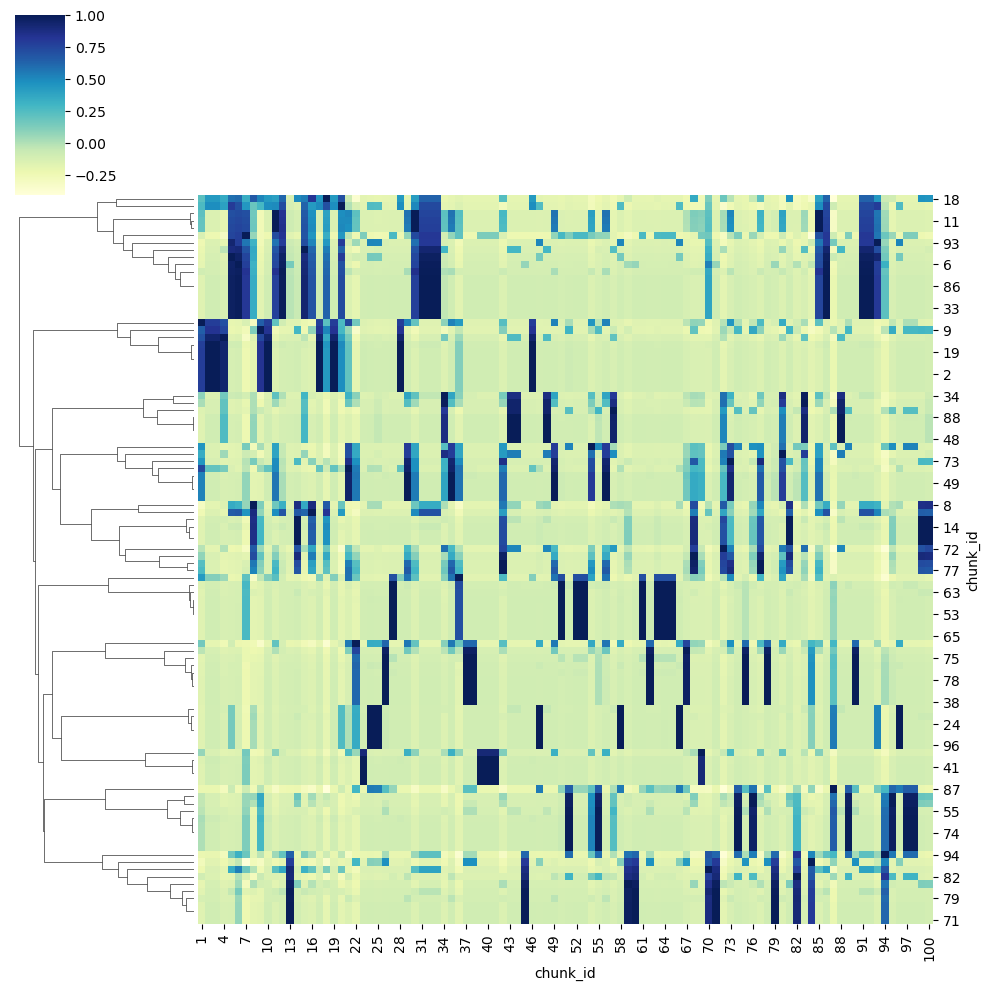

In [241]:
sns.clustermap(k.THETA.T.corr(), cmap="YlGnBu", col_cluster=False)

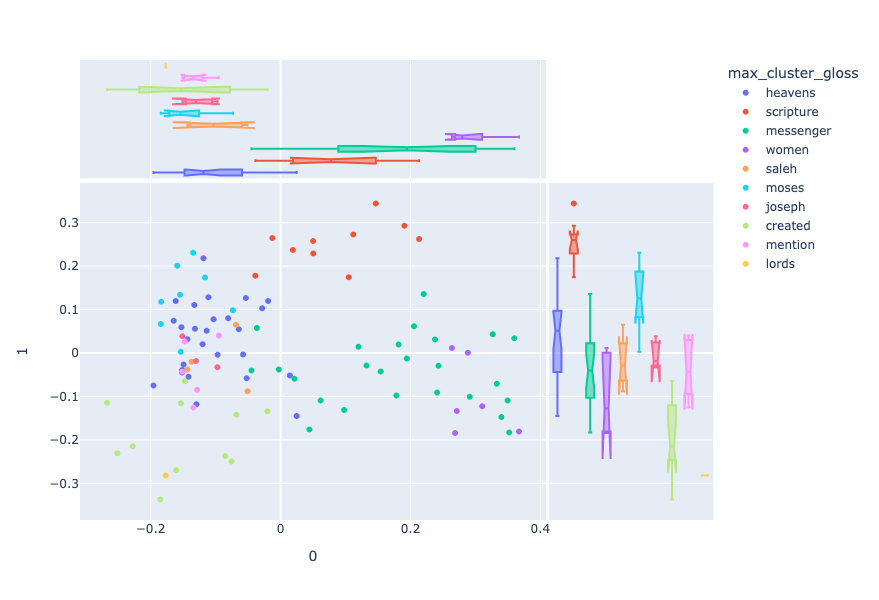

In [263]:
px.scatter(k.PCAX.join(k.DOC), 0,1, color='max_cluster_gloss', 
           hover_name=k.PCAX.index, height=600, width=700,
          marginal_x='box', marginal_y='box')

In [248]:
k.DOC

,n_tokens,cluster_label,max_cluster,max_cluster_gloss,top_topic_11,max_topic
chunk_id,,,,,,
1,1391,7,7,heavens,2,2
2,1391,3,3,scripture,2,2
3,1391,3,3,scripture,2,2
4,1391,3,3,scripture,2,2
5,1391,2,2,messenger,1,1
...,...,...,...,...,...,...
96,1390,7,7,heavens,8,8
97,1390,8,8,created,5,5
98,1390,8,8,created,5,5
